# Part 1

In [1]:
import pandas as pd
import numpy as np

# 1) Load the given dataset
df = pd.read_csv(r"D:\Ali\Project Portfolio\ML Projects\Logistic Reg\ML Project - Logistic Regression Titanic Survival.txt")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
# 2) Print all the column names 
print("--- Column Names ---")
print(df.columns.tolist())

--- Column Names ---
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [3]:
# 3) Describe the data 
print("\n--- Data Description ---")
print(df.describe())


--- Data Description ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [4]:
# 4) Check the null value 
print("\n--- Null Values ---")
print(df.isnull().sum())


--- Null Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# 5) Handle Null values and Pre-processing
# - Fill Age with Median
df['Age'] = df['Age'].fillna(df['Age'].median())
# - Fill Embarked with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# - Drop Cabin (too many nulls) and non-useful columns
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [6]:
# 6) Encoding categorical data for the model
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [7]:
print("\n--- Processed Data Info ---")
df.info()


--- Processed Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


# Part 2

In [8]:
# 1) Create the target data and feature data where target data is survived
X = df.drop('Survived', axis=1)
y = df['Survived']

In [9]:
from sklearn.model_selection import train_test_split

# 2) Split the data into Training and testing Set 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [10]:
from sklearn.linear_model import LogisticRegression

# 3) Create a Logistic regression model for Target and feature data 
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
log_reg.score(X_train, y_train)*100

80.6179775280899

In [12]:
log_reg.score(X_test, y_test)*100

80.44692737430168

In [13]:
# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

In [14]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_curve, auc)

# 4) Display the Confusion Matrix
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))


--- Confusion Matrix ---
[[91 13]
 [22 53]]


In [15]:
# 5) Find the Accuracy Score 
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

Accuracy Score: 0.8045


In [16]:
# 6) Find the Precision Score 
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")

Precision Score: 0.8030


In [17]:
# 7) Find the Recall Score 
print(f"Recall Score: {recall_score(y_test, y_pred):.4f}")

Recall Score: 0.7067


In [18]:
# 8) Find the F1 Score 
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

F1 Score: 0.7518


In [19]:
# 9) Probability
print("\nFirst 5 Testing Probabilities:\n", y_prob[:5])


First 5 Testing Probabilities:
 [0.78338894 0.73067998 0.09914748 0.64470163 0.16671673]


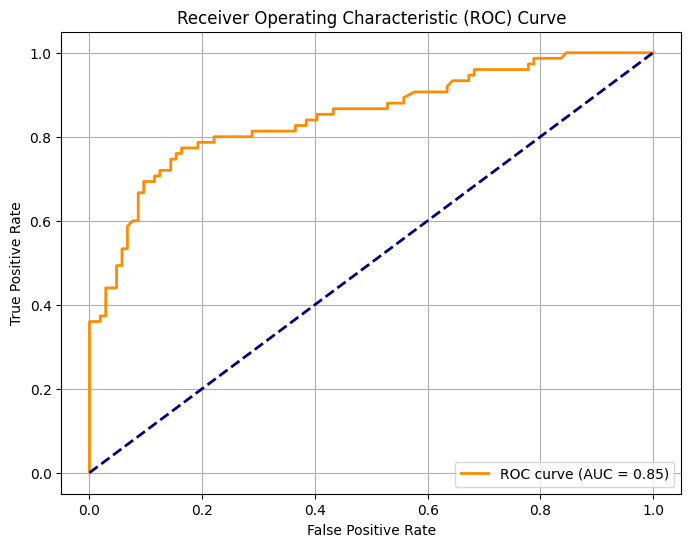


AUC Score: 0.8490


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 10) Display ROC Curve and find the AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")